# Delta-V Perturbation Analysis

This notebook analyzes the **Delta-V model**: a small additive network `delta_V_net` trained
on top of a frozen base model to capture the perturbation potential directly.

**Architecture**: `V_total(cos_q, sin_q) = V_net_frozen(cos_q, sin_q) + delta_V_net(cos_q, sin_q)`

Only `delta_V_net` is trainable — encoder, decoder, V_net, M_net, g_net are all hard-frozen.
This gives us a **clean, direct signal** for the perturbation, without the subtraction noise
that plagued the V_pert − V_unpert approach in notebook 4.

| Quantity | Notebook 4 (subtraction) | This notebook (Delta-V) |
|----------|--------------------------|-------------------------|
| ΔV | V_pert(φ) − V_unpert(φ) | delta_V_net(cos_q, sin_q) directly |
| Δa | a_pert(φ) − a_unpert(φ) | −(1/M) · d(delta_V)/dφ |
| Noise | High (two independent NNs) | Low (single small network) |

In [19]:
# Standard library imports
import os, sys
VENV_PATH = "/Users/harshit/Documents/UWM/F25/799-IS/Lagrangian_caVAE-main/.venv/lib/python3.9/site-packages"
if VENV_PATH not in sys.path:
    sys.path.append(VENV_PATH)

# Auto-detect project root
_cwd = os.path.abspath('')
PROJECT_ROOT = _cwd
for _ in range(5):
    if os.path.isdir(os.path.join(PROJECT_ROOT, 'examples')):
        break
    PROJECT_ROOT = os.path.dirname(PROJECT_ROOT)

if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

print(f"Project root: {PROJECT_ROOT}")

import torch
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from pytorch_lightning import seed_everything
from pysr import PySRRegressor

# Import BOTH model classes
from examples.pend_lag_cavae_trainer import Model  # original (unperturbed)
from examples.pend_delta_v_frozen_trainer import DeltaVFrozenModel  # delta-V

seed_everything(0)
%matplotlib inline

Project root: /Users/harshit/Documents/UWM/F25/799-IS/Lagrangian_caVAE-main


## Configuration

In [20]:
# ============================================================
# CONFIGURATION
# ============================================================

# Checkpoints
CKPT_UNPERTURBED = 'pend-lag-cavae-T_p=4-epoch=983-step=7871.ckpt'
CKPT_DELTA_V     = '_ckpt_epoch_845.ckpt'

# Ground-truth perturbation coefficients
# Δa = -α₁·θ - α₂·θ² - α₃·θ³
ETA1, ETA2, ETA3 = -0.0481, 0.0113, 0.1125
M_TRUE, L_TRUE = 1.0, 1.0
ALPHA1 = 3 * ETA1 / (M_TRUE * L_TRUE**2)   # -0.1443
ALPHA2 = 3 * ETA2 / (M_TRUE * L_TRUE**2)   #  0.0339
ALPHA3 = 3 * ETA3 / (M_TRUE * L_TRUE**2)   #  0.3375

# Sampling
N_SAMPLES = 500
THETA_MIN, THETA_MAX = 0, 2 * np.pi

# PySR hyperparameters
PYSR_NITERATIONS = 100
PYSR_MAXSIZE     = 25

# Plot settings
DPI = 600

print(f"True perturbation: Δa = {-ALPHA1:.4f}·θ + {-ALPHA2:.4f}·θ² + {-ALPHA3:.4f}·θ³")
print(f"  α₁ = {ALPHA1:.4f}, α₂ = {ALPHA2:.4f}, α₃ = {ALPHA3:.4f}")

True perturbation: Δa = 0.1443·θ + -0.0339·θ² + -0.3375·θ³
  α₁ = -0.1443, α₂ = 0.0339, α₃ = 0.3375


## 1. Load Models

Load the unperturbed base model (for phase offset calibration) and the Delta-V model.

In [21]:
ckpt_dir = os.path.join(PROJECT_ROOT, 'results', 'pend')

# Load unperturbed model (for calibration)
model_unpert = Model.load_from_checkpoint(
    os.path.join(ckpt_dir, CKPT_UNPERTURBED), map_location='cpu')
model_unpert.eval()
print("Unperturbed model loaded.")

# Load Delta-V model — need weights_only=False for old PL checkpoints
# PyTorch 2.6+ changed default weights_only from False to True
import pytorch_lightning as pl
_orig_torch_load = torch.load
def _patched_load(*args, **kwargs):
    kwargs.setdefault('weights_only', False)
    return _orig_torch_load(*args, **kwargs)
torch.load = _patched_load

model_delta_v = DeltaVFrozenModel.load_from_checkpoint(
    os.path.join(ckpt_dir, CKPT_DELTA_V), map_location='cpu')
model_delta_v.eval()

torch.load = _orig_torch_load  # restore original

# Verify delta_V_net exists and has trained weights
print(f"Delta-V model loaded.")
n_params = sum(p.numel() for p in model_delta_v.ode.delta_V_net.parameters())
print(f"  delta_V_net parameters: {n_params}")

Unperturbed model loaded.
Delta-V model loaded.
  delta_V_net parameters: 2751


## 2. Helper Functions

In [22]:
def extract_physics(model, theta_np):
    """Extract V(φ), M(φ), dV/dφ, and acceleration a(φ) from a trained model."""
    theta = torch.tensor(theta_np, dtype=torch.float32, requires_grad=True)
    cos_q = torch.cos(theta)
    sin_q = torch.sin(theta)
    cos_sin = torch.stack((cos_q, sin_q), dim=1)
    
    V = model.ode.V_net(cos_sin)
    M = model.ode.M_net(cos_sin)
    dV_dtheta = torch.autograd.grad(V.sum(), theta, create_graph=False)[0]
    
    M_flat = M.squeeze()
    acc = -(1.0 / M_flat) * dV_dtheta
    
    return {
        'theta': theta_np,
        'V':         V.detach().numpy().flatten(),
        'M':         M.detach().numpy().flatten(),
        'dVdtheta':  dV_dtheta.detach().numpy().flatten(),
        'acc':       acc.detach().numpy().flatten(),
    }


def extract_delta_v_physics(model, theta_np):
    """
    Extract delta_V_net output and its derived quantities.
    
    Returns delta_V(φ), d(delta_V)/dφ, and delta_a(φ) = -(1/M) * d(delta_V)/dφ.
    The M used is the frozen M_net from the same model.
    """
    theta = torch.tensor(theta_np, dtype=torch.float32, requires_grad=True)
    cos_q = torch.cos(theta)
    sin_q = torch.sin(theta)
    cos_sin = torch.stack((cos_q, sin_q), dim=1)
    
    # All network outputs
    delta_V = model.ode.delta_V_net(cos_sin)
    V_base = model.ode.V_net(cos_sin)
    M = model.ode.M_net(cos_sin)
    M_flat = M.squeeze()
    V_total = V_base + delta_V

    # Compute gradients — use retain_graph=True on first call
    # since delta_V and V_base share the same graph through cos_sin
    dV_total_dtheta = torch.autograd.grad(
        V_total.sum(), theta, retain_graph=True, create_graph=False
    )[0]
    d_delta_V_dtheta = torch.autograd.grad(
        delta_V.sum(), theta, create_graph=False
    )[0]

    delta_acc = -(1.0 / M_flat) * d_delta_V_dtheta
    total_acc = -(1.0 / M_flat) * dV_total_dtheta
    
    return {
        'theta':          theta_np,
        'delta_V':        delta_V.detach().numpy().flatten(),
        'd_delta_V':      d_delta_V_dtheta.detach().numpy().flatten(),
        'delta_acc':      delta_acc.detach().numpy().flatten(),
        'V_base':         V_base.detach().numpy().flatten(),
        'V_total':        V_total.detach().numpy().flatten(),
        'total_acc':      total_acc.detach().numpy().flatten(),
        'M':              M_flat.detach().numpy().flatten(),
    }


def calibrate_phase_offset(phi, a_unpert, g=10.0, l=1.0):
    """Find phase offset between NN angle φ and physical angle θ_phys."""
    K = 3 * g / (2 * l)
    
    best = None
    for s in [1.0, -1.0]:
        for off0 in np.linspace(0, 2*np.pi, 40):
            res = minimize(
                lambda o: np.mean((a_unpert - (-K * np.sin(s * (phi + o[0]))))**2),
                [off0], method='Nelder-Mead'
            )
            if best is None or res.fun < best[0]:
                best = (res.fun, s, res.x[0])
    
    mse, sign, offset = best
    res_free = minimize(
        lambda p: np.mean((a_unpert - (p[0] * np.sin(sign * (phi + offset))))**2),
        [-K], method='Nelder-Mead'
    )
    amp_fitted = res_free.x[0]
    
    return {
        'offset': offset, 'sign': sign, 'amplitude': amp_fitted,
        'mse': mse, 'expected_amplitude': -K,
    }


def phi_to_theta_phys(phi, calib):
    """Convert NN angle φ to physical angle θ_phys ∈ [-π, π]."""
    theta = calib['sign'] * (phi + calib['offset'])
    return ((theta + np.pi) % (2 * np.pi)) - np.pi


def run_pysr(X, y, niterations=100, maxsize=20, parsimony=0.005,
             binary_operators=['+', '-', '*'],
             unary_operators=[],
             variable_name='theta'):
    """Run PySR symbolic regression. Returns (model, best_idx, expr, pred)."""
    sr = PySRRegressor(
        niterations=niterations,
        binary_operators=binary_operators,
        unary_operators=unary_operators,
        denoise=False,
        model_selection='best',
        maxsize=maxsize,
        parsimony=parsimony,
        populations=30,
        population_size=50,
        ncycles_per_iteration=550,
        weight_optimize=0.001,
        adaptive_parsimony_scaling=1000,
        random_state=42,
        procs=4,
        temp_equation_file=True,
    )
    sr.fit(X, y, variable_names=[variable_name])
    
    eqs = sr.equations_
    scores = eqs['score'].values.astype(float)
    best_idx = eqs.index[np.argmax(scores)]
    
    expr = sr.sympy(index=best_idx)
    pred = sr.predict(X, index=best_idx)
    print(f"  Selected complexity {eqs['complexity'].values[np.argmax(scores)]:.0f} (max score)")
    print(f"  Expression: {expr}")
    return sr, best_idx, expr, pred


print("Helper functions defined.")

Helper functions defined.


## 3. Extract Physics & Calibrate Phase Offset

Use the unperturbed model to calibrate the phase offset, then extract
delta_V_net quantities in physical coordinates.

In [23]:
theta_range = np.linspace(THETA_MIN, THETA_MAX, N_SAMPLES)

# Extract base physics from unperturbed model (for calibration)
phys_unpert = extract_physics(model_unpert, theta_range)

# Calibrate phase offset
calib = calibrate_phase_offset(theta_range, phys_unpert['acc'])
print("Phase offset calibration:")
print(f"  sign    = {calib['sign']:+.0f}")
print(f"  offset  = {calib['offset']:.4f} rad ({np.degrees(calib['offset']):.1f} deg)")
print(f"  amplitude (fitted) = {calib['amplitude']:.2f}")
print(f"  amplitude (expected) = {calib['expected_amplitude']:.2f}")
print(f"  MSE = {calib['mse']:.4f}")

# Convert to physical coordinates
theta_phys = phi_to_theta_phys(theta_range, calib)
sort_idx = np.argsort(theta_phys)
theta_phys_sorted = theta_phys[sort_idx]

# Extract delta-V physics
delta_v_phys = extract_delta_v_physics(model_delta_v, theta_range)

# Sort everything to physical coordinates
delta_V_sorted     = delta_v_phys['delta_V'][sort_idx]
delta_V_sorted     = delta_V_sorted - delta_V_sorted[0]  # zero-anchor
delta_acc_sorted   = delta_v_phys['delta_acc'][sort_idx]
d_delta_V_sorted   = delta_v_phys['d_delta_V'][sort_idx]
V_base_sorted      = delta_v_phys['V_base'][sort_idx]
V_total_sorted     = delta_v_phys['V_total'][sort_idx]
total_acc_sorted   = delta_v_phys['total_acc'][sort_idx]
M_sorted           = delta_v_phys['M'][sort_idx]
a_unpert_sorted    = phys_unpert['acc'][sort_idx]

# M_scale: mean of learned mass matrix (needed for ΔV ground truth)
M_scale = np.mean(M_sorted)
print(f"M_scale (mean of learned M_net): {M_scale:.4f}")

print(f"Delta-V range: [{delta_V_sorted.min():.4f}, {delta_V_sorted.max():.4f}]")
print(f"Delta-a range: [{delta_acc_sorted.min():.4f}, {delta_acc_sorted.max():.4f}]")

Phase offset calibration:
  sign    = +1
  offset  = 2.2050 rad (126.3 deg)
  amplitude (fitted) = -15.45
  amplitude (expected) = -15.00
  MSE = 0.6618
M_scale (mean of learned M_net): 0.6915
Delta-V range: [-5.7057, 0.0999]
Delta-a range: [-8.5913, 13.3730]


## 4. Overview: Delta-V Network Output vs Ground Truth

Direct comparison of what delta_V_net learned vs. the true perturbation.

In [24]:
# Ground truth in physical coordinates
theta_gt = theta_phys_sorted
true_delta_a = -ALPHA1 * theta_gt - ALPHA2 * theta_gt**2 - ALPHA3 * theta_gt**3
true_delta_V_raw = M_scale * (
    (ALPHA1/2) * theta_gt**2 +
    (ALPHA2/3) * theta_gt**3 +
    (ALPHA3/4) * theta_gt**4
)
true_delta_V = true_delta_V_raw - true_delta_V_raw[0]  # zero-anchored

fig, axes = plt.subplots(2, 2, figsize=(16, 10), dpi=DPI)

# --- Top left: Delta-V (perturbation potential) ---
ax = axes[0, 0]
ax.plot(theta_gt, delta_V_sorted, 'b-', lw=2, label='delta_V_net')
ax.plot(theta_gt, true_delta_V, 'r--', lw=2, label='True ΔV')
ax.set_xlabel(r'$	heta_{\mathrm{phys}}$', fontsize=14)
ax.set_ylabel(r'$\Delta V$', fontsize=14)
ax.set_title('Perturbation Potential: delta_V_net vs Ground Truth')
ax.legend()
ax.grid(True, alpha=0.3)

# --- Top right: Delta-a (perturbation acceleration) ---
ax = axes[0, 1]
ax.plot(theta_gt, delta_acc_sorted, 'b-', lw=2, label='delta_a (from delta_V_net)')
ax.plot(theta_gt, true_delta_a, 'r--', lw=2, label='True Δa (ground truth)')
ax.set_xlabel(r'$	heta_{\mathrm{phys}}$', fontsize=14)
ax.set_ylabel(r'$\Delta a$', fontsize=14)
ax.set_title('Perturbation Acceleration: Delta-V derived vs Ground Truth')
ax.legend()
ax.grid(True, alpha=0.3)

# --- Bottom left: Total V ---
ax = axes[1, 0]
V_unpert_sorted = phys_unpert['V'].flatten()[sort_idx]
ax.plot(theta_gt, V_unpert_sorted, 'g-', lw=2, label='V_net (unperturbed model)')
ax.plot(theta_gt, V_base_sorted, 'b--', lw=1.5, label='V_net (frozen, in delta-V model)')
ax.plot(theta_gt, V_total_sorted, 'r-', lw=2, label='V_total = V_net + delta_V_net')
ax.set_xlabel(r'$	heta_{\mathrm{phys}}$', fontsize=14)
ax.set_ylabel('V', fontsize=14)
ax.set_title('Potential Energy Comparison')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# --- Bottom right: Total acceleration ---
ax = axes[1, 1]
a_true_base = -15.0 * np.sin(theta_gt)
a_true_total = a_true_base + true_delta_a
ax.plot(theta_gt, a_unpert_sorted, 'g-', lw=2, label='a (unperturbed NN)')
ax.plot(theta_gt, total_acc_sorted, 'b-', lw=2, label='a_total (delta-V model)')
ax.plot(theta_gt, a_true_total, 'r--', lw=2, label='True a_total (ground truth)')
ax.set_xlabel(r'$	heta_{\mathrm{phys}}$', fontsize=14)
ax.set_ylabel('a', fontsize=14)
ax.set_title('Total Acceleration Comparison')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print R² metrics
from sklearn.metrics import r2_score
r2_dv = r2_score(true_delta_V, delta_V_sorted)
r2_da = r2_score(true_delta_a, delta_acc_sorted)
print(f"R² (delta_V_net vs true ΔV): {r2_dv:.4f}")
print(f"R² (delta_a vs true Δa):     {r2_da:.4f}")

R² (delta_V_net vs true ΔV): 0.8130
R² (delta_a vs true Δa):     0.8225


In [ ]:
# Extended range — evaluate on wider phi range for full picture
phi_ext = np.linspace(-2*np.pi, 2*np.pi, 1000)
phys_unpert_ext = extract_physics(model_unpert, phi_ext)
dv_phys_ext = extract_delta_v_physics(model_delta_v, phi_ext)

# Convert to theta_phys using same calibration
theta_phys_ext_unwrapped = calib['sign'] * (phi_ext + calib['offset'])
theta_center = calib['sign'] * calib['offset']
theta_phys_ext_unwrapped = theta_phys_ext_unwrapped - np.round(theta_center / (2*np.pi)) * 2*np.pi
sort_ext = np.argsort(theta_phys_ext_unwrapped)
theta_ext_sorted = theta_phys_ext_unwrapped[sort_ext]

# Build "perturbed" dict from delta-V model for consistent plotting with NB7
phys_pert_ext = {
    'V':   dv_phys_ext['V_total'],
    'M':   dv_phys_ext['M'],
    'acc': dv_phys_ext['total_acc'],
}

# --- True potential in NN scale ---
# From calibration: a = -K_fitted * sin(θ_phys), and a = -(1/M) dV/dθ
# So V_true = -M_scale * |K_fitted| * cos(θ_phys) + offset
# Align offset to match learned V_unpert at θ=0
K_fitted = abs(calib['amplitude'])
V_true_unpert_ext = -M_scale * K_fitted * np.cos(theta_ext_sorted)
V_learned_unpert_ext = phys_unpert_ext['V'].flatten()[sort_ext]
V_true_unpert_ext += np.mean(V_learned_unpert_ext) - np.mean(V_true_unpert_ext)

V_true_pert_ext = V_true_unpert_ext + true_delta_V_raw_fn(theta_ext_sorted, M_scale)

fig, axes = plt.subplots(2, 3, figsize=(18, 10), dpi=DPI)

labels = ['Unperturbed', 'Delta-V (V_total)']
colors = ['#377eb8', '#e41a1c']
data_ext = [phys_unpert_ext, phys_pert_ext]

# Row 1: Raw V, M, acc on extended range
for i, (key, ylabel, title) in enumerate([
    ('V',   r'$V(\theta_{\mathrm{phys}})$',          'Potential Energy'),
    ('M',   r'$M(\theta_{\mathrm{phys}})$',          'Mass Matrix'),
    ('acc', r'$\ddot{\theta}$',  r'Acceleration ($\dot{\theta}=0$)'),
]):
    for d, label, c in zip(data_ext, labels, colors):
        axes[0, i].plot(theta_ext_sorted, d[key][sort_ext], color=c, lw=2, label=label, alpha=0.8)
    axes[0, i].set_xlabel(r'$\theta_{\mathrm{phys}}$', fontsize=14)
    axes[0, i].set_ylabel(ylabel, fontsize=14)
    axes[0, i].set_title(title, fontsize=13)
    axes[0, i].legend(fontsize=9)
    axes[0, i].grid(True, alpha=0.3)
    axes[0, i].axvline(x=-np.pi, color='gray', ls=':', alpha=0.4)
    axes[0, i].axvline(x=np.pi, color='gray', ls=':', alpha=0.4)
    axes[0, i].set_xlim(-1.5*np.pi, 1.5*np.pi)

# Add true V curves to Potential Energy plot (row 1, col 0)
axes[0, 0].plot(theta_ext_sorted, V_true_unpert_ext, 'g--', lw=2, alpha=0.7, label='True V (unpert)')
axes[0, 0].plot(theta_ext_sorted, V_true_pert_ext, 'm--', lw=2, alpha=0.7, label='True V (pert)')
axes[0, 0].legend(fontsize=8)

# Add true acceleration to Acceleration plot (row 1, col 2)
a_true_unpert_ext = -K_fitted * np.sin(theta_ext_sorted)
a_true_pert_ext = a_true_unpert_ext + true_delta_a_fn(theta_ext_sorted, M_scale)
axes[0, 2].plot(theta_ext_sorted, a_true_unpert_ext, 'g--', lw=2, alpha=0.7, label='True a (unpert)')
axes[0, 2].plot(theta_ext_sorted, a_true_pert_ext, 'm--', lw=2, alpha=0.7, label='True a (pert)')
axes[0, 2].legend(fontsize=8)

# Row 2: Differences on [-pi, pi] (using delta_V_net output directly)
ax = axes[1, 0]
ax.plot(theta_phys_sorted, delta_V_sorted, 'purple', lw=2, label=r'$\Delta V$ (delta_V_net)')
ax.plot(theta_phys_sorted, true_delta_V, 'r--', lw=2, label='True ΔV')
ax.set_xlabel(r'$\theta_{\mathrm{phys}}$', fontsize=14)
ax.set_ylabel(r'$\Delta V$', fontsize=14)
ax.set_title('Perturbation Potential (delta_V_net)', fontsize=13)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

ax = axes[1, 1]
M_unpert_sorted = phys_unpert['M'].flatten()[sort_idx]
M_dv_sorted = delta_v_phys['M'][sort_idx]
M_diff = M_dv_sorted - M_unpert_sorted
ax.plot(theta_phys_sorted, M_diff, 'purple', lw=2)
ax.set_xlabel(r'$\theta_{\mathrm{phys}}$', fontsize=14)
ax.set_ylabel(r'$\Delta M$', fontsize=14)
ax.set_title('Mass Difference (should be ~0, M frozen)', fontsize=13)
ax.grid(True, alpha=0.3)

ax = axes[1, 2]
ax.plot(theta_phys_sorted, delta_acc_sorted, 'purple', lw=2, label=r'$\Delta a$ (delta_V_net)')
ax.plot(theta_phys_sorted, true_delta_a, 'r--', lw=2, label='True Δa')
ax.set_xlabel(r'$\theta_{\mathrm{phys}}$', fontsize=14)
ax.set_ylabel(r'$\Delta a$', fontsize=14)
ax.set_title('Perturbation Acceleration (from delta_V_net)', fontsize=13)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Row 1: Unperturbed vs Delta-V total (V_base + delta_V_net), with true V curves (dashed)")
print("Row 2: delta_V_net output directly (not subtraction of two models)")

## 5. Polynomial Regression on Delta-V Signal

Since delta_V_net directly outputs the perturbation, polynomial regression
should work much better than on the noisy V_pert − V_unpert subtraction.

In [26]:
from numpy.polynomial import polynomial as P

print("=" * 60)
print("POLYNOMIAL REGRESSION ON delta_V_net OUTPUT")
print("=" * 60)

# --- 5a. Polynomial fit to delta_V(θ) ---
print("\n--- 5a. Fit delta_V(θ) with polynomial ---")
print(f"True: ΔV = M_scale*(α₁/2·θ² + α₂/3·θ³ + α₃/4·θ⁴), M_scale={M_scale:.4f}")
print(f"     = {M_scale*ALPHA1/2:.4f}·θ² + {M_scale*ALPHA2/3:.4f}·θ³ + {M_scale*ALPHA3/4:.4f}·θ⁴")

for deg in [4, 5, 6]:
    coeffs = np.polyfit(theta_phys_sorted, delta_V_sorted, deg)
    poly_pred = np.polyval(coeffs, theta_phys_sorted)
    r2 = 1 - np.sum((delta_V_sorted - poly_pred)**2) / np.sum((delta_V_sorted - delta_V_sorted.mean())**2)
    
    print(f"\n  Degree {deg} (R² = {r2:.6f}):")
    for i, c in enumerate(coeffs):
        power = deg - i
        if abs(c) > 1e-6:
            print(f"    θ^{power}: {c:+.6f}", end='')
            # Compare with true coefficient for key terms
            if power == 4:
                print(f"  (true: {M_scale*ALPHA3/4:.6f}, ratio: {c/(M_scale*ALPHA3/4):.3f})", end='')
            elif power == 3:
                print(f"  (true: {M_scale*ALPHA2/3:.6f}, ratio: {c/(M_scale*ALPHA2/3) if abs(ALPHA2/3) > 1e-8 else float('inf'):.3f})", end='')
            elif power == 2:
                print(f"  (true: {M_scale*ALPHA1/2:.6f}, ratio: {c/(M_scale*ALPHA1/2):.3f})", end='')
            print()

# --- 5b. Polynomial fit to delta_a(θ) ---
print("\n\n--- 5b. Fit delta_a(θ) with polynomial ---")
print("True: Δa = -α₁·θ - α₂·θ² - α₃·θ³")
print(f"     = {-ALPHA1:.4f}·θ + {-ALPHA2:.4f}·θ² + {-ALPHA3:.4f}·θ³")

for deg in [3, 4, 5]:
    coeffs = np.polyfit(theta_phys_sorted, delta_acc_sorted, deg)
    poly_pred = np.polyval(coeffs, theta_phys_sorted)
    r2 = 1 - np.sum((delta_acc_sorted - poly_pred)**2) / np.sum((delta_acc_sorted - delta_acc_sorted.mean())**2)
    
    print(f"Degree {deg} (R² = {r2:.6f}):")
    for i, c in enumerate(coeffs):
        power = deg - i
        if abs(c) > 1e-6:
            print(f"    θ^{power}: {c:+.6f}", end='')
            if power == 3:
                print(f"  (true: {-ALPHA3:.6f}, ratio: {c/(-ALPHA3):.3f})", end='')
            elif power == 2:
                print(f"  (true: {-ALPHA2:.6f}, ratio: {c/(-ALPHA2) if abs(ALPHA2) > 1e-8 else float('inf'):.3f})", end='')
            elif power == 1:
                print(f"  (true: {-ALPHA1:.6f}, ratio: {c/(-ALPHA1):.3f})", end='')
            print()

POLYNOMIAL REGRESSION ON delta_V_net OUTPUT

--- 5a. Fit delta_V(θ) with polynomial ---
True: ΔV = M_scale*(α₁/2·θ² + α₂/3·θ³ + α₃/4·θ⁴), M_scale=0.6915
     = -0.0499·θ² + 0.0078·θ³ + 0.0583·θ⁴

  Degree 4 (R² = 0.997480):
    θ^4: +0.064722  (true: 0.058347, ratio: 1.109)
    θ^3: -0.057326  (true: 0.007814, ratio: -7.336)
    θ^2: -0.098810  (true: -0.049893, ratio: 1.980)
    θ^1: +0.630618
    θ^0: -5.097806

  Degree 5 (R² = 0.997491):
    θ^5: -0.000449
    θ^4: +0.064728  (true: 0.058347, ratio: 1.109)
    θ^3: -0.052401  (true: 0.007814, ratio: -6.706)
    θ^2: -0.098852  (true: -0.049893, ratio: 1.981)
    θ^1: +0.620188
    θ^0: -5.097778

  Degree 6 (R² = 0.997536):
    θ^6: +0.000549
    θ^5: -0.000455
    θ^4: +0.057332  (true: 0.058347, ratio: 0.983)
    θ^3: -0.052348  (true: 0.007814, ratio: -6.699)
    θ^2: -0.074512  (true: -0.049893, ratio: 1.493)
    θ^1: +0.620107
    θ^0: -5.109219


--- 5b. Fit delta_a(θ) with polynomial ---
True: Δa = -α₁·θ - α₂·θ² - α₃·θ³
    

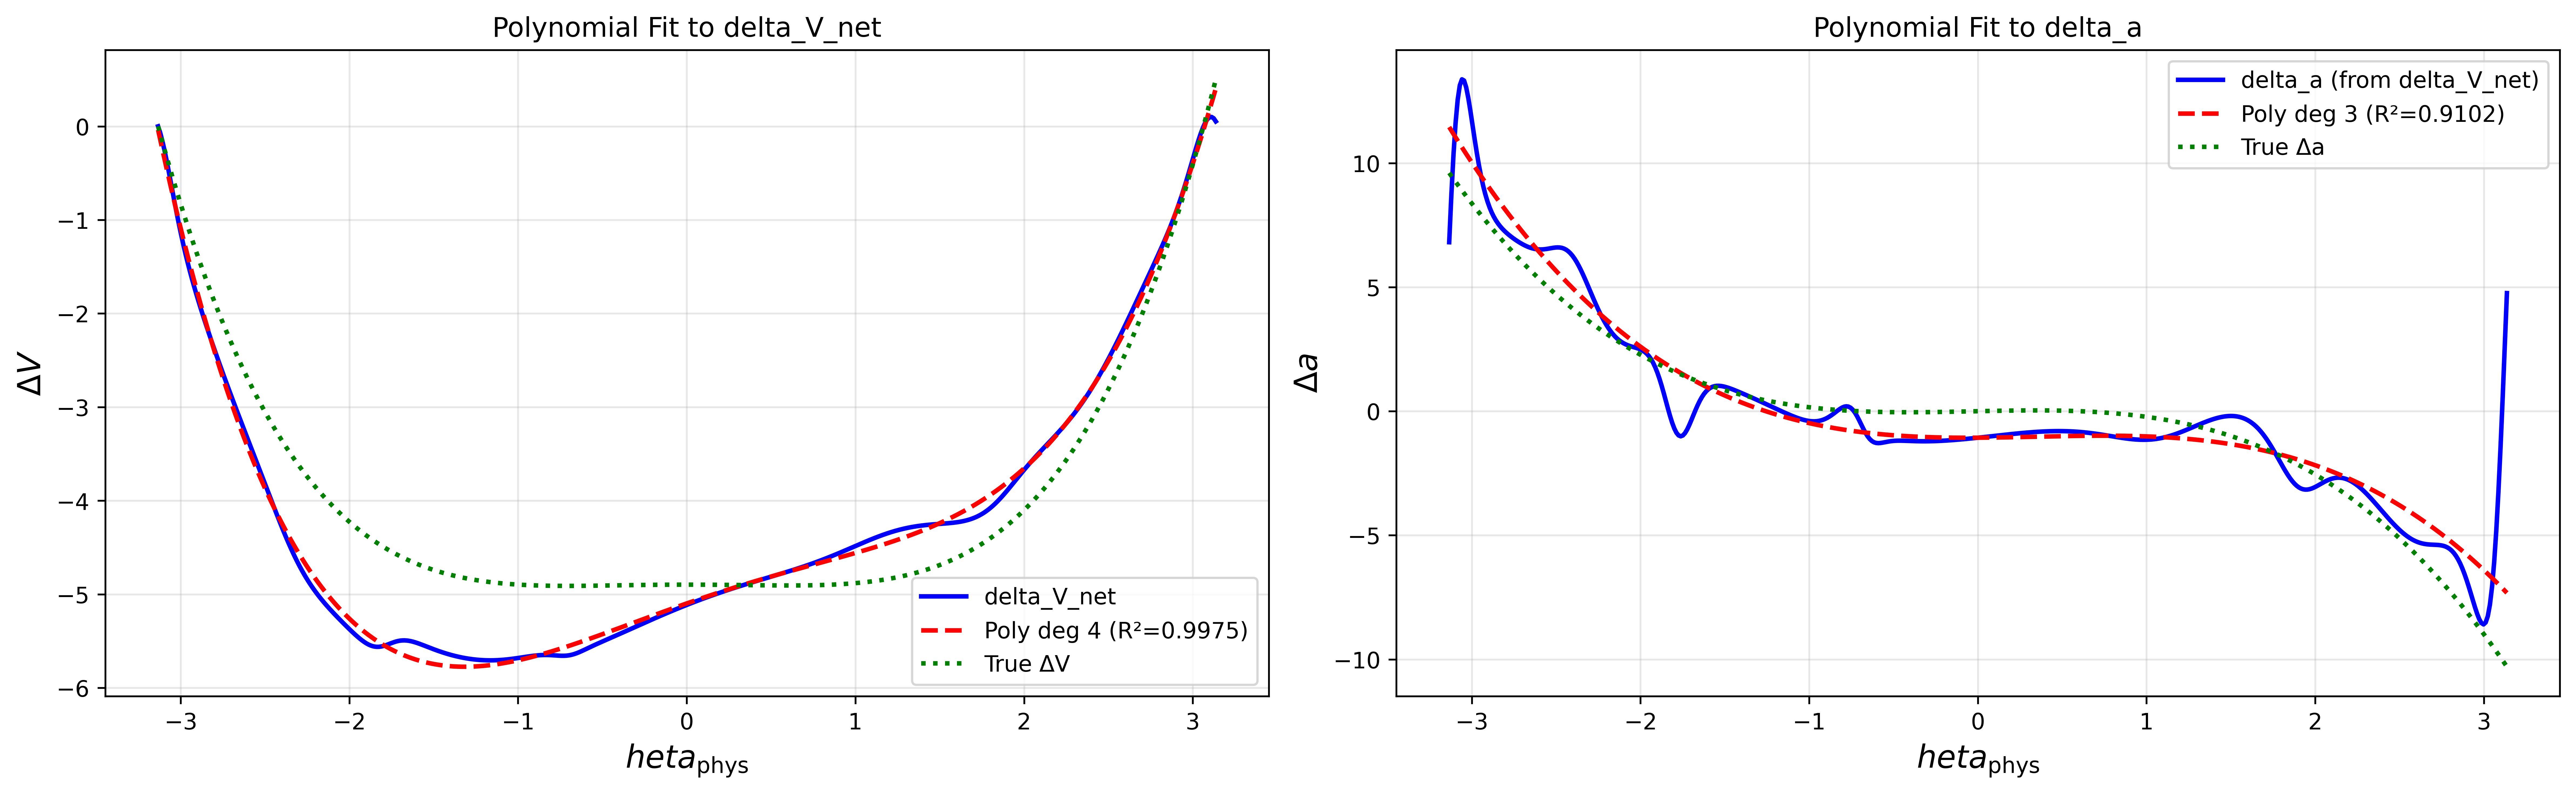

In [27]:
# Plot best polynomial fits
fig, axes = plt.subplots(1, 2, figsize=(16, 5), dpi=DPI)

# Delta-V
coeffs_dv = np.polyfit(theta_phys_sorted, delta_V_sorted, 4)
poly_dv = np.polyval(coeffs_dv, theta_phys_sorted)

ax = axes[0]
ax.plot(theta_gt, delta_V_sorted, 'b-', lw=2, label='delta_V_net')
ax.plot(theta_gt, poly_dv, 'r--', lw=2, label=f'Poly deg 4 (R²={1-np.sum((delta_V_sorted-poly_dv)**2)/np.sum((delta_V_sorted-delta_V_sorted.mean())**2):.4f})')
ax.plot(theta_gt, true_delta_V, 'g:', lw=2, label='True ΔV')
ax.set_xlabel(r'$	heta_{\mathrm{phys}}$', fontsize=14)
ax.set_ylabel(r'$\Delta V$', fontsize=14)
ax.set_title('Polynomial Fit to delta_V_net')
ax.legend()
ax.grid(True, alpha=0.3)

# Delta-a
coeffs_da = np.polyfit(theta_phys_sorted, delta_acc_sorted, 3)
poly_da = np.polyval(coeffs_da, theta_phys_sorted)

ax = axes[1]
ax.plot(theta_gt, delta_acc_sorted, 'b-', lw=2, label='delta_a (from delta_V_net)')
ax.plot(theta_gt, poly_da, 'r--', lw=2, label=f'Poly deg 3 (R²={1-np.sum((delta_acc_sorted-poly_da)**2)/np.sum((delta_acc_sorted-delta_acc_sorted.mean())**2):.4f})')
ax.plot(theta_gt, true_delta_a, 'g:', lw=2, label='True Δa')
ax.set_xlabel(r'$	heta_{\mathrm{phys}}$', fontsize=14)
ax.set_ylabel(r'$\Delta a$', fontsize=14)
ax.set_title('Polynomial Fit to delta_a')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. SINDy: Sparse Identification of Nonlinear Dynamics

Apply SINDy with polynomial-only library to the Delta-V signal.
Based on notebook 4 findings, we use polynomial-only basis to avoid
poly/trig collinearity issues.

In [28]:
import pysindy as ps

print("=" * 60)
print("SINDy ON DELTA-V NETWORK OUTPUT")
print("=" * 60)

X_sindy = theta_phys_sorted.reshape(-1, 1)

# --- 6a. SINDy on delta_a(θ) ---
print("\n--- 6a. SINDy on Δa (from delta_V_net) ---")
print(f"True: Δa = {-ALPHA1:.4f}·θ + {-ALPHA2:.4f}·θ² + {-ALPHA3:.4f}·θ³")

y_da = delta_acc_sorted.reshape(-1, 1)
poly_lib = ps.PolynomialLibrary(degree=5, include_bias=True)
thresholds = np.logspace(-3, 0, 20)

results_da = []
for thr in thresholds:
    optimizer = ps.STLSQ(threshold=thr, alpha=1e-5, max_iter=50)
    sindy_model = ps.SINDy(feature_library=poly_lib, optimizer=optimizer)
    sindy_model.fit(X_sindy, t=1, x_dot=y_da, feature_names=['theta'])
    
    pred = sindy_model.predict(X_sindy)
    ss_res = np.sum((y_da - pred)**2)
    ss_tot = np.sum((y_da - y_da.mean())**2)
    r2 = 1 - ss_res / ss_tot
    
    coeffs = sindy_model.coefficients().flatten()
    n_active = np.sum(np.abs(coeffs) > 1e-10)
    
    results_da.append({
        'threshold': thr, 'r2': r2, 'n_active': n_active,
        'coeffs': coeffs, 'model': sindy_model,
        'equations': sindy_model.equations()
    })

# Select: best R² with <= 4 active terms
candidates = [r for r in results_da if r['n_active'] <= 4 and r['r2'] > 0.5]
if candidates:
    best_da = max(candidates, key=lambda r: r['r2'])
else:
    best_da = max(results_da, key=lambda r: r['r2'])

print(f"\nBest SINDy (Δa): R² = {best_da['r2']:.4f}, {best_da['n_active']} active terms")
print(f"  Equation: {best_da['equations']}")
print(f"  Threshold: {best_da['threshold']:.4f}")

# Show coefficient table
feature_names = best_da['model'].get_feature_names()
print(f"\n  {'Feature':<12} {'SINDy':>10} {'True':>10} {'Ratio':>8}")
print(f"  {'-'*42}")
true_da_coeffs = {'1': 0, 'theta': -ALPHA1, 'theta^2': -ALPHA2, 'theta^3': -ALPHA3}
for fname, coeff in zip(feature_names, best_da['coeffs']):
    if abs(coeff) > 1e-10:
        true_val = true_da_coeffs.get(fname, 0)
        ratio = coeff / true_val if abs(true_val) > 1e-8 else float('inf')
        print(f"  {fname:<12} {coeff:>10.4f} {true_val:>10.4f} {ratio:>8.3f}")

/Users/harshit/miniconda3/envs/lagrangian_clean/lib/python3.9/site-packages/pysindy/optimizers/stlsq.py:224: UserWarning: Sparsity parameter is too big (0.3359818286283781) and eliminated all coefficients
  warnings.warn(
/Users/harshit/miniconda3/envs/lagrangian_clean/lib/python3.9/site-packages/pysindy/optimizers/stlsq.py:224: UserWarning: Sparsity parameter is too big (0.4832930238571752) and eliminated all coefficients
  warnings.warn(
/Users/harshit/miniconda3/envs/lagrangian_clean/lib/python3.9/site-packages/pysindy/optimizers/stlsq.py:224: UserWarning: Sparsity parameter is too big (0.6951927961775606) and eliminated all coefficients
  warnings.warn(
/Users/harshit/miniconda3/envs/lagrangian_clean/lib/python3.9/site-packages/pysindy/optimizers/stlsq.py:224: UserWarning: Sparsity parameter is too big (1.0) and eliminated all coefficients
  warnings.warn(


SINDy ON DELTA-V NETWORK OUTPUT

--- 6a. SINDy on Δa (from delta_V_net) ---
True: Δa = 0.1443·θ + -0.0339·θ² + -0.3375·θ³

Best SINDy (Δa): R² = 0.9151, 4 active terms
  Equation: ['-0.749 1 + 0.043 theta + -0.309 theta^3 + 0.038 theta^4']
  Threshold: 0.0264

  Feature           SINDy       True    Ratio
  ------------------------------------------
  1               -0.7491     0.0000      inf
  theta            0.0428     0.1443    0.296
  theta^3         -0.3091    -0.3375    0.916
  theta^4          0.0377     0.0000      inf


In [29]:
# --- 6b. SINDy on delta_V(θ) ---
print("\n--- 6b. SINDy on ΔV (from delta_V_net) ---")
print(f"True: ΔV = {M_scale*ALPHA1/2:.4f}·θ² + {M_scale*ALPHA2/3:.4f}·θ³ + {M_scale*ALPHA3/4:.4f}·θ⁴  (M_scale={M_scale:.4f})")

y_dv = delta_V_sorted.reshape(-1, 1)
poly_lib = ps.PolynomialLibrary(degree=6, include_bias=True)

results_dv = []
for thr in thresholds:
    optimizer = ps.STLSQ(threshold=thr, alpha=1e-5, max_iter=50)
    sindy_model = ps.SINDy(feature_library=poly_lib, optimizer=optimizer)
    sindy_model.fit(X_sindy, t=1, x_dot=y_dv, feature_names=['theta'])
    
    pred = sindy_model.predict(X_sindy)
    ss_res = np.sum((y_dv - pred)**2)
    ss_tot = np.sum((y_dv - y_dv.mean())**2)
    r2 = 1 - ss_res / ss_tot
    
    coeffs = sindy_model.coefficients().flatten()
    n_active = np.sum(np.abs(coeffs) > 1e-10)
    
    results_dv.append({
        'threshold': thr, 'r2': r2, 'n_active': n_active,
        'coeffs': coeffs, 'model': sindy_model,
        'equations': sindy_model.equations()
    })

candidates = [r for r in results_dv if r['n_active'] <= 5 and r['r2'] > 0.5]
if candidates:
    best_dv = max(candidates, key=lambda r: r['r2'])
else:
    best_dv = max(results_dv, key=lambda r: r['r2'])

print(f"\nBest SINDy (ΔV): R² = {best_dv['r2']:.4f}, {best_dv['n_active']} active terms")
print(f"  Equation: {best_dv['equations']}")
print(f"  Threshold: {best_dv['threshold']:.4f}")

# Show coefficient table
feature_names = best_dv['model'].get_feature_names()
print(f"\n  {'Feature':<12} {'SINDy':>10} {'True':>10} {'Ratio':>8}")
print(f"  {'-'*42}")
true_dv_coeffs = {'1': 0, 'theta': 0, 'theta^2': M_scale*ALPHA1/2, 'theta^3': M_scale*ALPHA2/3, 'theta^4': M_scale*ALPHA3/4}
for fname, coeff in zip(feature_names, best_dv['coeffs']):
    if abs(coeff) > 1e-10:
        true_val = true_dv_coeffs.get(fname, 0)
        ratio = coeff / true_val if abs(true_val) > 1e-8 else float('inf')
        print(f"  {fname:<12} {coeff:>10.6f} {true_val:>10.6f} {ratio:>8.3f}")


--- 6b. SINDy on ΔV (from delta_V_net) ---
True: ΔV = -0.0499·θ² + 0.0078·θ³ + 0.0583·θ⁴  (M_scale=0.6915)

Best SINDy (ΔV): R² = 0.9975, 5 active terms
  Equation: ['-5.098 1 + 0.631 theta + -0.099 theta^2 + -0.057 theta^3 + 0.065 theta^4']
  Threshold: 0.0010

  Feature           SINDy       True    Ratio
  ------------------------------------------
  1             -5.097806   0.000000      inf
  theta          0.630618   0.000000      inf
  theta^2       -0.098810  -0.049893    1.980
  theta^3       -0.057326   0.007814   -7.336
  theta^4        0.064722   0.058347    1.109


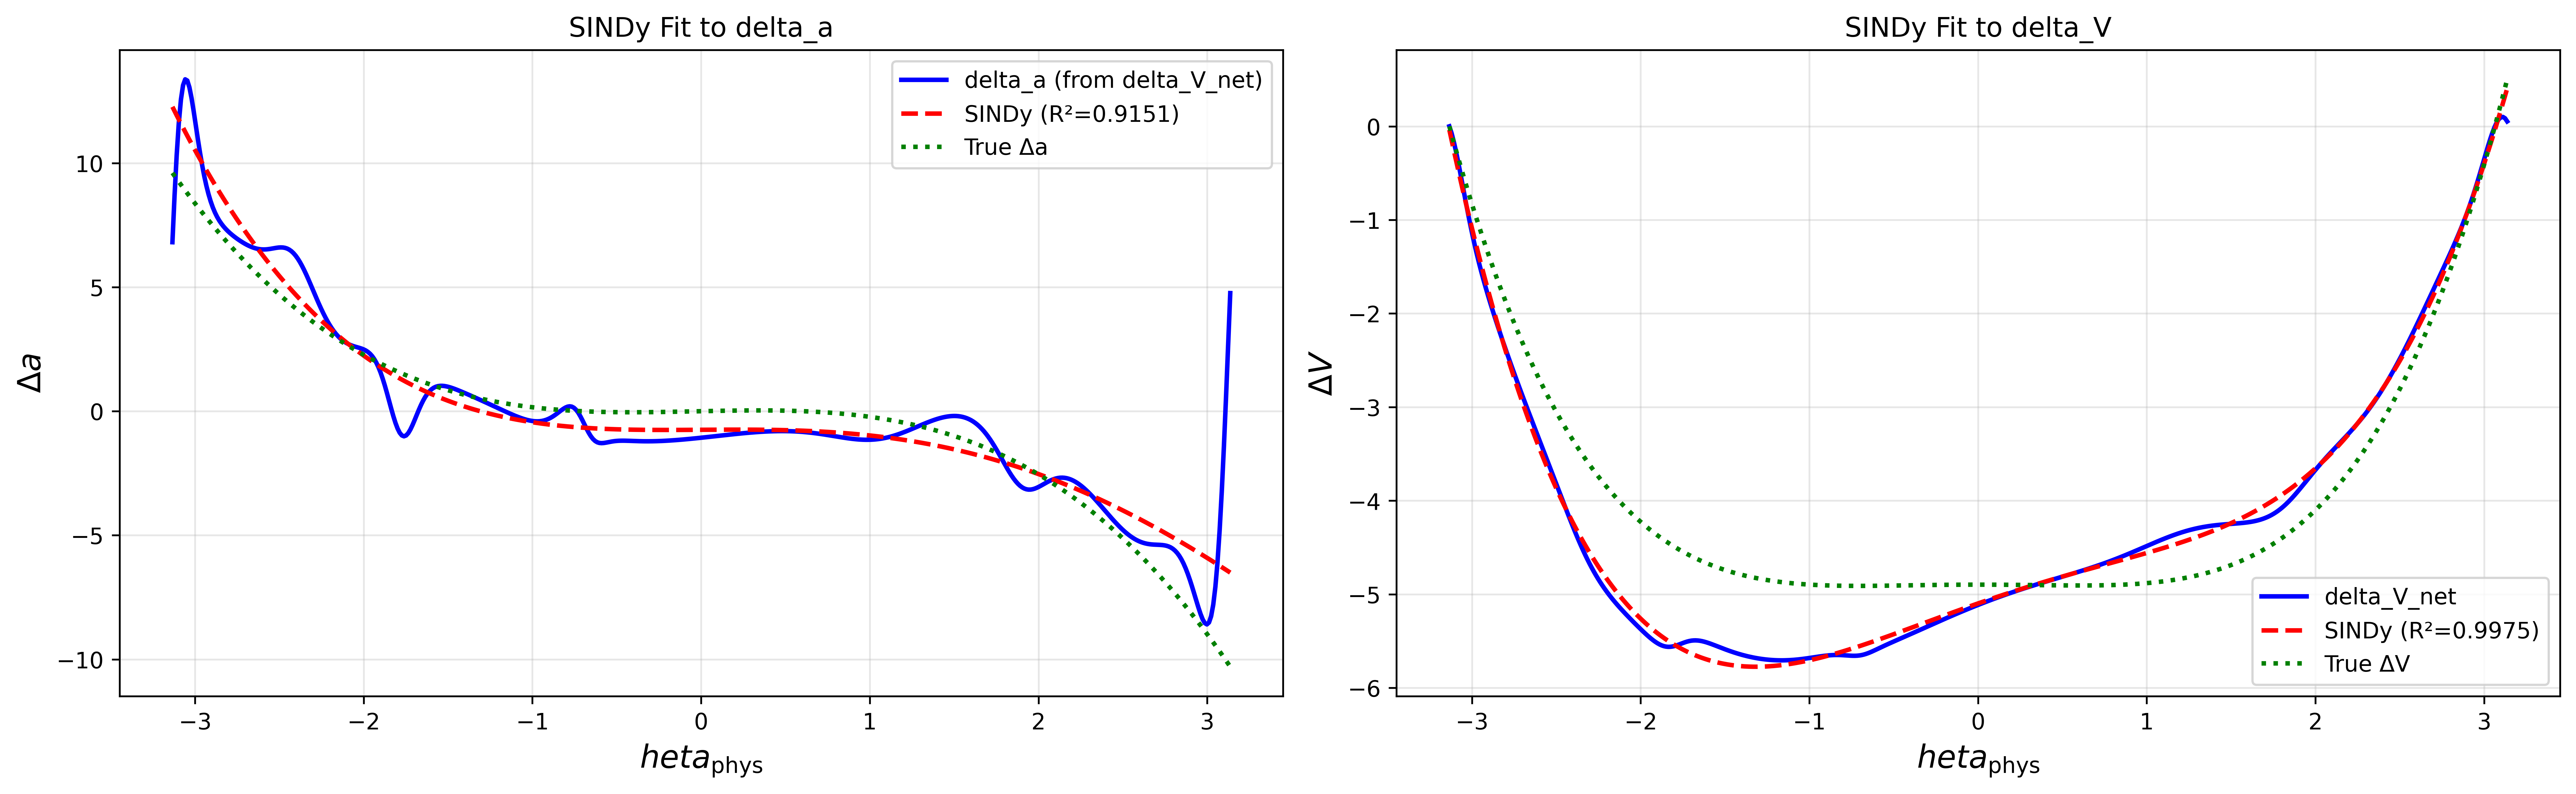

In [30]:
# Plot SINDy fits
fig, axes = plt.subplots(1, 2, figsize=(16, 5), dpi=DPI)

# Δa
sindy_pred_da = np.array(best_da['model'].predict(X_sindy)).flatten()
ax = axes[0]
ax.plot(theta_gt, delta_acc_sorted, 'b-', lw=2, label='delta_a (from delta_V_net)')
ax.plot(theta_gt, sindy_pred_da, 'r--', lw=2, label=f'SINDy (R²={best_da["r2"]:.4f})')
ax.plot(theta_gt, true_delta_a, 'g:', lw=2, label='True Δa')
ax.set_xlabel(r'$	heta_{\mathrm{phys}}$', fontsize=14)
ax.set_ylabel(r'$\Delta a$', fontsize=14)
ax.set_title('SINDy Fit to delta_a')
ax.legend()
ax.grid(True, alpha=0.3)

# ΔV
sindy_pred_dv = np.array(best_dv['model'].predict(X_sindy)).flatten()
ax = axes[1]
ax.plot(theta_gt, delta_V_sorted, 'b-', lw=2, label='delta_V_net')
ax.plot(theta_gt, sindy_pred_dv, 'r--', lw=2, label=f'SINDy (R²={best_dv["r2"]:.4f})')
ax.plot(theta_gt, true_delta_V, 'g:', lw=2, label='True ΔV')
ax.set_xlabel(r'$	heta_{\mathrm{phys}}$', fontsize=14)
ax.set_ylabel(r'$\Delta V$', fontsize=14)
ax.set_title('SINDy Fit to delta_V')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. PySR Symbolic Regression on Delta-V Signal

Apply PySR with polynomial operators to the clean delta_V_net signal.

In [31]:
print("=" * 60)
print("PySR ON DELTA-V NETWORK OUTPUT")
print("=" * 60)

# --- 7a. PySR on delta_a(θ) ---
print("\n--- 7a. PySR on Δa (from delta_V_net) ---")
X_pysr = theta_phys_sorted.reshape(-1, 1)

sr_da, idx_da, expr_da, pred_da = run_pysr(
    X_pysr, delta_acc_sorted,
    niterations=PYSR_NITERATIONS,
    maxsize=PYSR_MAXSIZE,
    parsimony=0.005,
    binary_operators=['+', '-', '*'],
    unary_operators=[],
    variable_name='theta',
)

PySR ON DELTA-V NETWORK OUTPUT

--- 7a. PySR on Δa (from delta_V_net) ---


/Users/harshit/miniconda3/envs/lagrangian_clean/lib/python3.9/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
/Users/harshit/miniconda3/envs/lagrangian_clean/lib/python3.9/site-packages/pysr/sr.py:1873: UserWarning: Note: Setting `random_state` without also setting `deterministic=True` and `parallelism='serial'` will result in non-deterministic searches.
  warnings.warn(
[ Info: Started!



Expressions evaluated per second: 5.330e+05
Progress: 1037 / 3000 total iterations (34.567%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           1.479e+01  0.000e+00  y = -0.02509
3           4.299e+00  6.178e-01  y = theta * -1.7851
5           4.299e+00  2.450e-05  y = (-0.0081733 - theta) * 1.7851
7           2.214e+00  3.318e-01  y = (theta * (theta * -0.30268)) * theta
9           1.834e+00  9.400e-02  y = (theta * theta) * (0.13953 - (theta * 0.30293))
11          1.329e+00  1.613e-01  y = (((theta + -1.056) * -0.30298) * (theta * theta)) - 1....
                                      0678
13          1.256e+00  2.795e-02  y = (theta * (((theta * 0.037706) - 0.30301) * (theta * th...
                                      eta))) - 0.74907
15          1.255e+00  3.830e-04  y = (the

[ Info: Final population:
[ Info: Results saved to:


───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           1.479e+01  0.000e+00  y = -0.02509
3           4.299e+00  6.178e-01  y = theta * -1.7851
5           4.299e+00  2.450e-05  y = (-0.0081733 - theta) * 1.7851
7           2.214e+00  3.318e-01  y = (theta * (theta * -0.30268)) * theta
9           1.834e+00  9.400e-02  y = (theta * theta) * (0.13953 - (theta * 0.30293))
11          1.329e+00  1.613e-01  y = (((theta + -1.056) * -0.30298) * (theta * theta)) - 1....
                                      0678
13          1.256e+00  2.795e-02  y = (theta * (((theta * 0.037706) - 0.30301) * (theta * th...
                                      eta))) - 0.74907
15          1.255e+00  3.830e-04  y = (theta * (((theta * theta) * ((theta * 0.037705) - 0.3...
                                      0909)) + 0.042827)) - 0.74912
17          1.220e+00  1.424e-02  y = (-2.065 - ((theta * theta) * theta)

In [32]:
# --- 7b. PySR on delta_V(θ) ---
print("\n--- 7b. PySR on ΔV (from delta_V_net) ---")

sr_dv, idx_dv, expr_dv, pred_dv = run_pysr(
    X_pysr, delta_V_sorted,
    niterations=PYSR_NITERATIONS,
    maxsize=PYSR_MAXSIZE,
    parsimony=0.005,
    binary_operators=['+', '-', '*'],
    unary_operators=[],
    variable_name='theta',
)

/Users/harshit/miniconda3/envs/lagrangian_clean/lib/python3.9/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
/Users/harshit/miniconda3/envs/lagrangian_clean/lib/python3.9/site-packages/pysr/sr.py:1873: UserWarning: Note: Setting `random_state` without also setting `deterministic=True` and `parallelism='serial'` will result in non-deterministic searches.
  warnings.warn(
[ Info: Started!
[ Info: Final population:
[ Info: Results saved to:



--- 7b. PySR on ΔV (from delta_V_net) ---

Expressions evaluated per second: 7.160e+05
Progress: 1517 / 3000 total iterations (50.567%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           2.329e+00  0.000e+00  y = -4.1601
5           2.045e+00  3.245e-02  y = (theta * 0.29341) + -4.1618
7           5.868e-01  6.243e-01  y = ((theta * 0.44885) * theta) + -5.6382
9           3.077e-01  3.229e-01  y = (((theta + 0.64955) * theta) * 0.44829) - 5.638
13          8.470e-02  3.225e-01  y = (theta * (((theta * theta) * (0.053958 * theta)) + 0.2...
                                      9126)) + -5.2134
15          1.278e-02  9.456e-01  y = (theta * (((theta * ((theta - 1.0604) * theta)) * 0.05...
                                      3994) + 0.63013)) + -5.2141
17          5.870e-03  3.891e-01

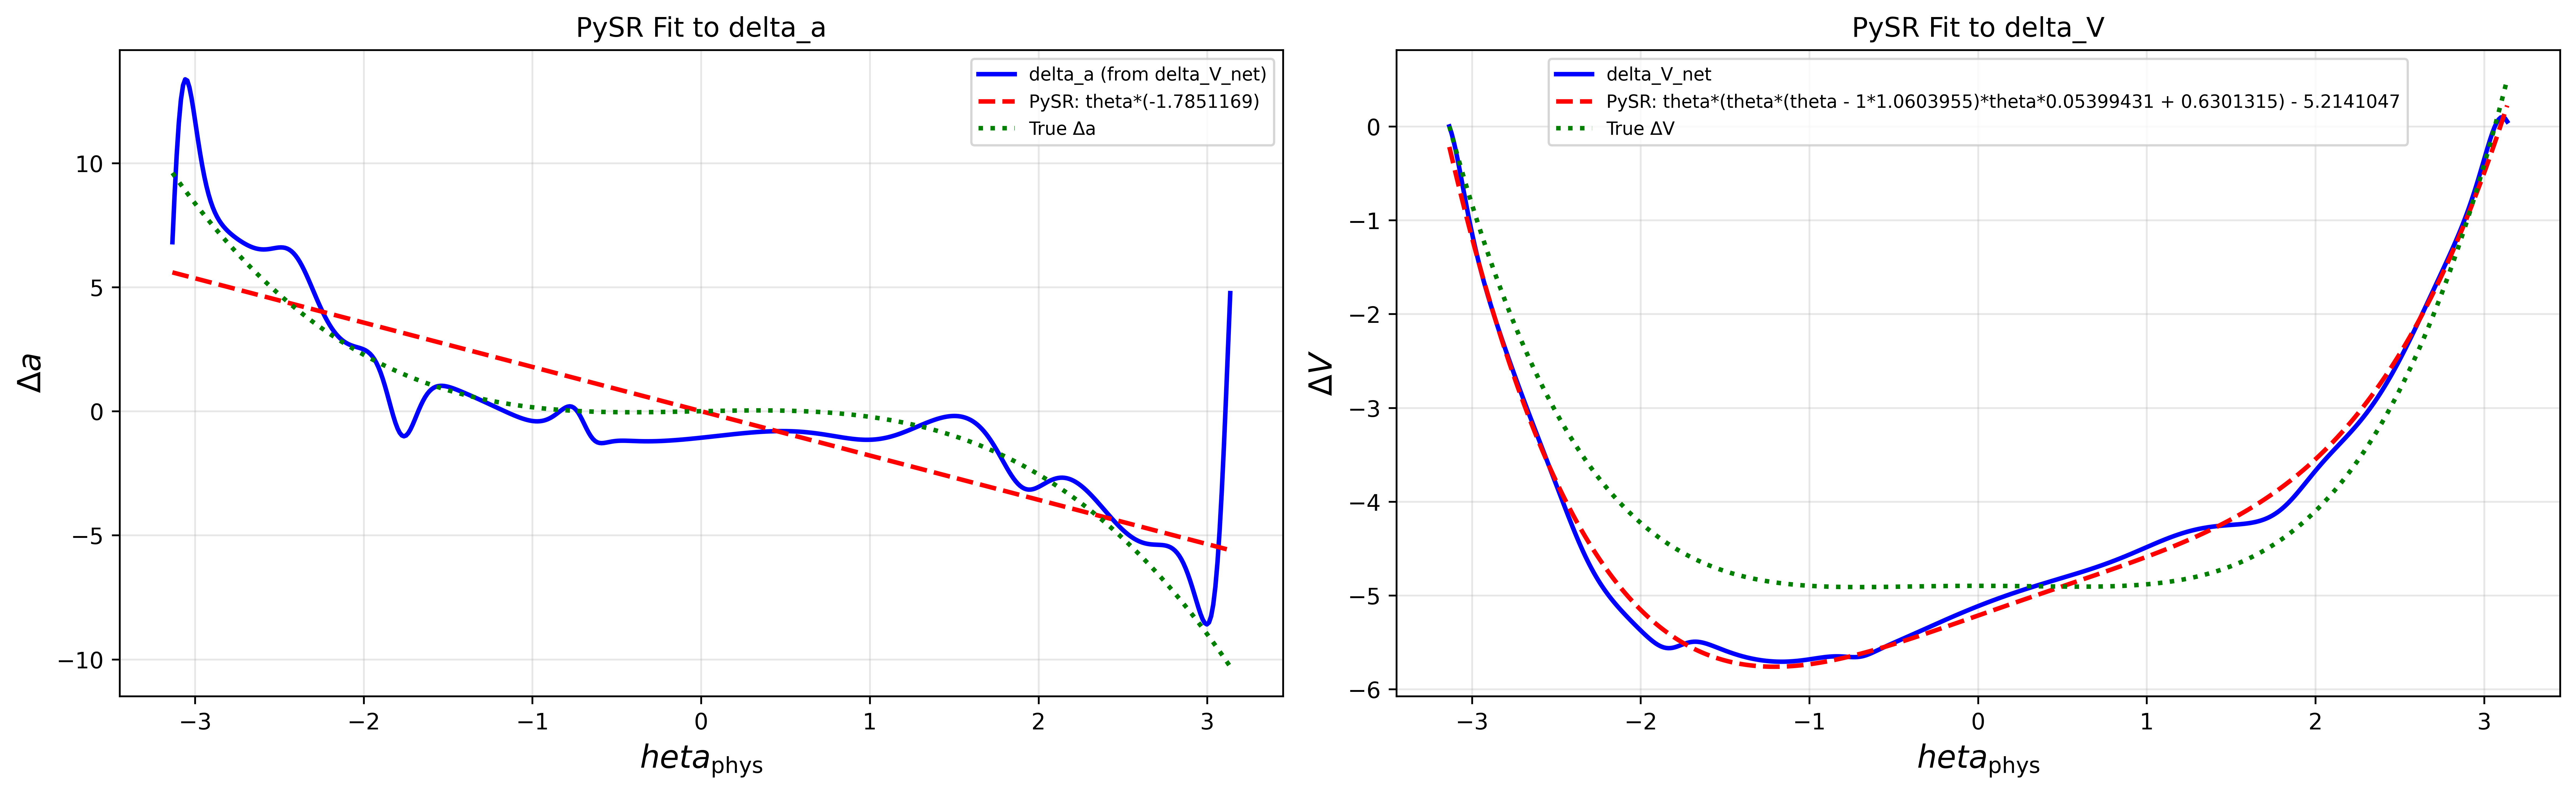

In [33]:
# Plot PySR fits
fig, axes = plt.subplots(1, 2, figsize=(16, 5), dpi=DPI)

ax = axes[0]
ax.plot(theta_gt, delta_acc_sorted, 'b-', lw=2, label='delta_a (from delta_V_net)')
ax.plot(theta_gt, pred_da, 'r--', lw=2, label=f'PySR: {expr_da}')
ax.plot(theta_gt, true_delta_a, 'g:', lw=2, label='True Δa')
ax.set_xlabel(r'$	heta_{\mathrm{phys}}$', fontsize=14)
ax.set_ylabel(r'$\Delta a$', fontsize=14)
ax.set_title('PySR Fit to delta_a')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(theta_gt, delta_V_sorted, 'b-', lw=2, label='delta_V_net')
ax.plot(theta_gt, pred_dv, 'r--', lw=2, label=f'PySR: {expr_dv}')
ax.plot(theta_gt, true_delta_V, 'g:', lw=2, label='True ΔV')
ax.set_xlabel(r'$	heta_{\mathrm{phys}}$', fontsize=14)
ax.set_ylabel(r'$\Delta V$', fontsize=14)
ax.set_title('PySR Fit to delta_V')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Expand PySR Expressions to Polynomial Form

Extract polynomial coefficients from PySR expressions for direct comparison.

In [34]:
import sympy as sp

theta_sym = sp.Symbol('theta')

def expand_to_poly_coeffs(expr, symbol=theta_sym, max_degree=5):
    """Expand a sympy expression to polynomial coefficients."""
    poly = sp.Poly(sp.expand(expr), symbol)
    coeffs = {}
    for monom, coeff in poly.as_dict().items():
        degree = monom[0]
        coeffs[degree] = float(coeff)
    return coeffs

print("=" * 60)
print("PySR EXPRESSIONS → POLYNOMIAL COEFFICIENTS")
print("=" * 60)

# Δa
print("\n--- Δa expression ---")
print(f"  PySR: {expr_da}")
try:
    da_coeffs = expand_to_poly_coeffs(expr_da)
    print(f"  Expanded: ", end='')
    for deg in sorted(da_coeffs.keys()):
        print(f"{da_coeffs[deg]:+.4f}·θ^{deg} ", end='')
    print()
    print(f"\n  Coefficient comparison:")
    true_da = {1: -ALPHA1, 2: -ALPHA2, 3: -ALPHA3}
    for deg in sorted(set(list(da_coeffs.keys()) + list(true_da.keys()))):
        pysr_val = da_coeffs.get(deg, 0)
        true_val = true_da.get(deg, 0)
        ratio = pysr_val / true_val if abs(true_val) > 1e-8 else float('inf')
        print(f"    θ^{deg}: PySR={pysr_val:+.4f}, True={true_val:+.4f}, Ratio={ratio:.3f}")
except Exception as e:
    print(f"  Could not expand: {e}")

# ΔV
print("\n--- ΔV expression ---")
print(f"  PySR: {expr_dv}")
try:
    dv_coeffs = expand_to_poly_coeffs(expr_dv)
    print(f"  Expanded: ", end='')
    for deg in sorted(dv_coeffs.keys()):
        print(f"{dv_coeffs[deg]:+.6f}·θ^{deg} ", end='')
    print()
    print(f"\n  Coefficient comparison:")
    true_dv = {2: M_scale*ALPHA1/2, 3: M_scale*ALPHA2/3, 4: M_scale*ALPHA3/4}
    for deg in sorted(set(list(dv_coeffs.keys()) + list(true_dv.keys()))):
        pysr_val = dv_coeffs.get(deg, 0)
        true_val = true_dv.get(deg, 0)
        ratio = pysr_val / true_val if abs(true_val) > 1e-8 else float('inf')
        print(f"    θ^{deg}: PySR={pysr_val:+.6f}, True={true_val:+.6f}, Ratio={ratio:.3f}")
except Exception as e:
    print(f"  Could not expand: {e}")

PySR EXPRESSIONS → POLYNOMIAL COEFFICIENTS

--- Δa expression ---
  PySR: theta*(-1.7851169)
  Expanded: -1.7851·θ^1 

  Coefficient comparison:
    θ^1: PySR=-1.7851, True=+0.1443, Ratio=-12.371
    θ^2: PySR=+0.0000, True=-0.0339, Ratio=-0.000
    θ^3: PySR=+0.0000, True=-0.3375, Ratio=-0.000

--- ΔV expression ---
  PySR: theta*(theta*(theta - 1*1.0603955)*theta*0.05399431 + 0.6301315) - 5.2141047
  Expanded: -5.214105·θ^0 +0.630131·θ^1 -0.057255·θ^3 +0.053994·θ^4 

  Coefficient comparison:
    θ^0: PySR=-5.214105, True=+0.000000, Ratio=inf
    θ^1: PySR=+0.630131, True=+0.000000, Ratio=inf
    θ^2: PySR=+0.000000, True=-0.049893, Ratio=-0.000
    θ^3: PySR=-0.057255, True=+0.007814, Ratio=-7.327
    θ^4: PySR=+0.053994, True=+0.058347, Ratio=0.925


## 9. Comparison: Delta-V Architecture vs Subtraction (Notebook 4)

Compare the coefficient recovery from this notebook (clean delta_V_net signal)
with notebook 4 (noisy V_pert − V_unpert subtraction).

**Notebook 4 results** (from polynomial regression):
- Δa θ³ coefficient: −0.319 (true: −0.338, ratio: 0.95)
- Δa θ² coefficient: +0.33 (true: −0.034, **wrong sign**)
- ΔV θ⁴ coefficient: +0.067 (true: +0.058, ratio: 1.15)

The key question: **does the clean delta_V_net signal improve lower-order term recovery?**

In [35]:
print("=" * 70)
print("  COMPARISON: Delta-V Architecture vs Subtraction Approach")
print("=" * 70)

# Best polynomial regression results from this notebook
coeffs_da_best = np.polyfit(theta_phys_sorted, delta_acc_sorted, 3)
coeffs_dv_best = np.polyfit(theta_phys_sorted, delta_V_sorted, 4)

# Notebook 4 results (hardcoded from previous analysis)
nb4_da_theta3 = -0.319
nb4_da_theta2 = 0.33
nb4_da_theta1 = None  # not reliably recovered
nb4_dv_theta4 = 0.067

print(f"\n{'Coefficient':<15} {'True':>10} {'NB4 (subtr)':>12} {'NB5 (ΔV-net)':>12} {'NB4 ratio':>10} {'NB5 ratio':>10}")
print(f"{'-'*70}")

# Δa coefficients (from degree-3 fit: coeffs order is [θ³, θ², θ¹, θ⁰])
da_theta3 = coeffs_da_best[0]
da_theta2 = coeffs_da_best[1]
da_theta1 = coeffs_da_best[2]

true_vals = {
    'Δa: θ³': (-ALPHA3, nb4_da_theta3, da_theta3),
    'Δa: θ²': (-ALPHA2, nb4_da_theta2, da_theta2),
    'Δa: θ¹': (-ALPHA1, None, da_theta1),
}

for name, (true, nb4, nb5) in true_vals.items():
    nb4_str = f"{nb4:.4f}" if nb4 is not None else "N/A"
    nb4_ratio = f"{nb4/true:.3f}" if (nb4 is not None and abs(true) > 1e-8) else "N/A"
    nb5_ratio = f"{nb5/true:.3f}" if abs(true) > 1e-8 else "inf"
    print(f"{name:<15} {true:>10.4f} {nb4_str:>12} {nb5:>12.4f} {nb4_ratio:>10} {nb5_ratio:>10}")

# ΔV coefficients (from degree-4 fit: coeffs order is [θ⁴, θ³, θ², θ¹, θ⁰])
dv_theta4 = coeffs_dv_best[0]
dv_theta3 = coeffs_dv_best[1]
dv_theta2 = coeffs_dv_best[2]

print(f"\n{'Coefficient':<15} {'True':>10} {'NB4 (subtr)':>12} {'NB5 (ΔV-net)':>12} {'NB4 ratio':>10} {'NB5 ratio':>10}")
print(f"{'-'*70}")

dv_vals = {
    'ΔV: θ⁴': (M_scale*ALPHA3/4, nb4_dv_theta4, dv_theta4),
    'ΔV: θ³': (M_scale*ALPHA2/3, None, dv_theta3),
    'ΔV: θ²': (M_scale*ALPHA1/2, None, dv_theta2),
}

for name, (true, nb4, nb5) in dv_vals.items():
    nb4_str = f"{nb4:.6f}" if nb4 is not None else "N/A"
    nb4_ratio = f"{nb4/true:.3f}" if (nb4 is not None and abs(true) > 1e-8) else "N/A"
    nb5_ratio = f"{nb5/true:.3f}" if abs(true) > 1e-8 else "inf"
    print(f"{name:<15} {true:>10.6f} {nb4_str:>12} {nb5:>12.6f} {nb4_ratio:>10} {nb5_ratio:>10}")

print("\n" + "=" * 70)
print("Key: ratio = recovered/true (1.000 = perfect recovery)")
print("=" * 70)

  COMPARISON: Delta-V Architecture vs Subtraction Approach

Coefficient           True  NB4 (subtr) NB5 (ΔV-net)  NB4 ratio  NB5 ratio
----------------------------------------------------------------------
Δa: θ³             -0.3375      -0.3190      -0.3088      0.945      0.915
Δa: θ²             -0.0339       0.3300       0.3199     -9.735     -9.438
Δa: θ¹              0.1443          N/A       0.0409        N/A      0.284

Coefficient           True  NB4 (subtr) NB5 (ΔV-net)  NB4 ratio  NB5 ratio
----------------------------------------------------------------------
ΔV: θ⁴            0.058347     0.067000     0.064722      1.148      1.109
ΔV: θ³            0.007814          N/A    -0.057326        N/A     -7.336
ΔV: θ²           -0.049893          N/A    -0.098810        N/A      1.980

Key: ratio = recovered/true (1.000 = perfect recovery)



## 10. Summary Report

In [36]:
from sklearn.metrics import r2_score
import sympy as sp

print("=" * 80)
print("     DELTA-V PERTURBATION ANALYSIS — SUMMARY REPORT")
print("=" * 80)

# ---- Ground truth ----
true_dv_t4 = M_scale * ALPHA3 / 4
true_dv_t3 = M_scale * ALPHA2 / 3
true_dv_t2 = M_scale * ALPHA1 / 2

print(f"\nTrue perturbation:")
print(f"  Δa = {-ALPHA1:.4f}·θ + {-ALPHA2:.4f}·θ² + {-ALPHA3:.4f}·θ³")
print(f"  ΔV = {true_dv_t2:.6f}·θ² + {true_dv_t3:.6f}·θ³ + {true_dv_t4:.6f}·θ⁴  (×M_scale={M_scale:.4f})")

# ---- R² ----
r2_dv = r2_score(true_delta_V, delta_V_sorted)
r2_da = r2_score(true_delta_a, delta_acc_sorted)
print(f"\nR² (signal quality):")
print(f"  delta_V_net vs true ΔV: {r2_dv:.4f}")
print(f"  delta_a vs true Δa:     {r2_da:.4f}")

# ============================================================
# 1. Polynomial Regression
# ============================================================
print(f"\n{'='*80}")
print("  1. POLYNOMIAL REGRESSION")
print(f"{'='*80}")

c_da = np.polyfit(theta_phys_sorted, delta_acc_sorted, 3)
c_dv = np.polyfit(theta_phys_sorted, delta_V_sorted, 4)

poly_da_pred = np.polyval(c_da, theta_phys_sorted)
poly_dv_pred = np.polyval(c_dv, theta_phys_sorted)
r2_poly_da = 1 - np.sum((delta_acc_sorted - poly_da_pred)**2) / np.sum((delta_acc_sorted - delta_acc_sorted.mean())**2)
r2_poly_dv = 1 - np.sum((delta_V_sorted - poly_dv_pred)**2) / np.sum((delta_V_sorted - delta_V_sorted.mean())**2)

print(f"\n  Δa (degree 3, R²={r2_poly_da:.4f}):")
print(f"    {'Term':<8} {'Fitted':>12} {'True':>12} {'Ratio':>10} {'Status':>10}")
print(f"    {'-'*54}")
for i, (power, true_val) in enumerate([(3, -ALPHA3), (2, -ALPHA2), (1, -ALPHA1), (0, 0)]):
    ratio = f"{c_da[i]/true_val:.3f}" if abs(true_val) > 1e-8 else ("SPURIOUS" if abs(c_da[i]) > 0.01 else "~0")
    status = "OK" if (abs(true_val) > 1e-8 and 0.8 < abs(c_da[i]/true_val) < 1.2) else ("SPURIOUS" if abs(true_val) < 1e-8 and abs(c_da[i]) > 0.01 else "~0" if abs(c_da[i]) < 0.01 else "OFF")
    print(f"    θ^{power:<5} {c_da[i]:>12.4f} {true_val:>12.4f} {ratio:>10} {status:>10}")

print(f"\n  ΔV (degree 4, R²={r2_poly_dv:.4f}):")
print(f"    {'Term':<8} {'Fitted':>12} {'True':>12} {'Ratio':>10} {'Status':>10}")
print(f"    {'-'*54}")
true_dv_list = [true_dv_t4, true_dv_t3, true_dv_t2, 0, 0]
for i, power in enumerate([4, 3, 2, 1, 0]):
    true_val = true_dv_list[i]
    ratio = f"{c_dv[i]/true_val:.3f}" if abs(true_val) > 1e-8 else ("SPURIOUS" if abs(c_dv[i]) > 0.001 else "~0")
    status = "OK" if (abs(true_val) > 1e-8 and 0.8 < abs(c_dv[i]/true_val) < 1.2) else ("SPURIOUS" if abs(true_val) < 1e-8 and abs(c_dv[i]) > 0.001 else "~0" if abs(c_dv[i]) < 0.001 else "OFF")
    print(f"    θ^{power:<5} {c_dv[i]:>12.6f} {true_val:>12.6f} {ratio:>10} {status:>10}")

# ============================================================
# 2. SINDy
# ============================================================
print(f"\n{'='*80}")
print("  2. SINDy (Sparse Identification of Nonlinear Dynamics)")
print(f"{'='*80}")

print(f"\n  Δa: {best_da['equations'][0]}")
print(f"       R²={best_da['r2']:.4f}, {best_da['n_active']} active terms, threshold={best_da['threshold']:.4f}")
print(f"    {'Feature':<15} {'SINDy':>12} {'True':>12} {'Ratio':>10}")
print(f"    {'-'*51}")
true_da_map = {'1': 0, 'theta': -ALPHA1, 'theta^2': -ALPHA2, 'theta^3': -ALPHA3, 'theta^4': 0, 'theta^5': 0}
for fname, coeff in zip(best_da['model'].get_feature_names(), best_da['coeffs']):
    if abs(coeff) > 1e-10:
        tv = true_da_map.get(fname, 0)
        ratio = f"{coeff/tv:.3f}" if abs(tv) > 1e-8 else ("SPURIOUS" if abs(coeff) > 0.01 else "~0")
        print(f"    {fname:<15} {coeff:>12.4f} {tv:>12.4f} {ratio:>10}")

print(f"\n  ΔV: {best_dv['equations'][0]}")
print(f"       R²={best_dv['r2']:.4f}, {best_dv['n_active']} active terms, threshold={best_dv['threshold']:.4f}")
print(f"    {'Feature':<15} {'SINDy':>12} {'True':>12} {'Ratio':>10}")
print(f"    {'-'*51}")
true_dv_map = {'1': 0, 'theta': 0, 'theta^2': true_dv_t2, 'theta^3': true_dv_t3, 'theta^4': true_dv_t4, 'theta^5': 0, 'theta^6': 0}
for fname, coeff in zip(best_dv['model'].get_feature_names(), best_dv['coeffs']):
    if abs(coeff) > 1e-10:
        tv = true_dv_map.get(fname, 0)
        ratio = f"{coeff/tv:.3f}" if abs(tv) > 1e-8 else ("SPURIOUS" if abs(coeff) > 0.001 else "~0")
        print(f"    {fname:<15} {coeff:>12.6f} {tv:>12.6f} {ratio:>10}")

# ============================================================
# 3. PySR
# ============================================================
print(f"\n{'='*80}")
print("  3. PySR (Symbolic Regression)")
print(f"{'='*80}")

theta_sym = sp.Symbol('theta')

def expand_to_poly(expr, symbol, max_deg=6):
    try:
        poly = sp.Poly(sp.expand(expr), symbol)
        return {m[0]: float(c) for m, c in poly.as_dict().items()}
    except:
        return None

print(f"\n  Δa: {expr_da}")
da_coeffs = expand_to_poly(expr_da, theta_sym)
if da_coeffs:
    print(f"    {'Degree':<8} {'PySR':>12} {'True':>12} {'Ratio':>10}")
    print(f"    {'-'*44}")
    max_d = max(max(da_coeffs.keys()), 3)
    true_da_by_deg = {1: -ALPHA1, 2: -ALPHA2, 3: -ALPHA3}
    for d in range(max_d + 1):
        pv = da_coeffs.get(d, 0)
        tv = true_da_by_deg.get(d, 0)
        if abs(pv) > 1e-6 or abs(tv) > 1e-6:
            ratio = f"{pv/tv:.3f}" if abs(tv) > 1e-8 else ("SPURIOUS" if abs(pv) > 0.01 else "~0")
            print(f"    θ^{d:<5} {pv:>12.4f} {tv:>12.4f} {ratio:>10}")

print(f"\n  ΔV: {expr_dv}")
dv_coeffs = expand_to_poly(expr_dv, theta_sym)
if dv_coeffs:
    print(f"    {'Degree':<8} {'PySR':>12} {'True':>12} {'Ratio':>10}")
    print(f"    {'-'*44}")
    max_d = max(max(dv_coeffs.keys()), 4)
    true_dv_by_deg = {2: true_dv_t2, 3: true_dv_t3, 4: true_dv_t4}
    for d in range(max_d + 1):
        pv = dv_coeffs.get(d, 0)
        tv = true_dv_by_deg.get(d, 0)
        if abs(pv) > 1e-6 or abs(tv) > 1e-6:
            ratio = f"{pv/tv:.3f}" if abs(tv) > 1e-8 else ("SPURIOUS" if abs(pv) > 0.001 else "~0")
            print(f"    θ^{d:<5} {pv:>12.6f} {tv:>12.6f} {ratio:>10}")

# ============================================================
# Comparison table
# ============================================================
print(f"\n{'='*80}")
print("  DOMINANT TERM RECOVERY COMPARISON")
print(f"{'='*80}")

# Δa θ³ coefficient from each method
poly_da3 = c_da[0]
sindy_da3 = 0
for fname, coeff in zip(best_da['model'].get_feature_names(), best_da['coeffs']):
    if fname == 'theta^3':
        sindy_da3 = coeff
pysr_da3 = expand_to_poly(expr_da, theta_sym).get(3, 0) if expand_to_poly(expr_da, theta_sym) else 0

# ΔV θ⁴ coefficient from each method
poly_dv4 = c_dv[0]
sindy_dv4 = 0
for fname, coeff in zip(best_dv['model'].get_feature_names(), best_dv['coeffs']):
    if fname == 'theta^4':
        sindy_dv4 = coeff
pysr_dv4 = expand_to_poly(expr_dv, theta_sym).get(4, 0) if expand_to_poly(expr_dv, theta_sym) else 0

print(f"\n  {'Method':<20} {'Δa θ³':>12} {'ratio':>8} {'ΔV θ⁴':>12} {'ratio':>8}")
print(f"  {'-'*62}")
print(f"  {'True':<20} {-ALPHA3:>12.4f} {'':>8} {true_dv_t4:>12.6f} {'':>8}")
print(f"  {'Poly Regression':<20} {poly_da3:>12.4f} {poly_da3/(-ALPHA3):>8.3f} {poly_dv4:>12.6f} {poly_dv4/true_dv_t4:>8.3f}")
print(f"  {'SINDy':<20} {sindy_da3:>12.4f} {sindy_da3/(-ALPHA3):>8.3f} {sindy_dv4:>12.6f} {sindy_dv4/true_dv_t4:>8.3f}")
print(f"  {'PySR':<20} {pysr_da3:>12.4f} {pysr_da3/(-ALPHA3):>8.3f} {pysr_dv4:>12.6f} {pysr_dv4/true_dv_t4:>8.3f}")

print(f"\n{'='*80}")


     DELTA-V PERTURBATION ANALYSIS — SUMMARY REPORT

True perturbation:
  Δa = 0.1443·θ + -0.0339·θ² + -0.3375·θ³
  ΔV = -0.049893·θ² + 0.007814·θ³ + 0.058347·θ⁴  (×M_scale=0.6915)

R² (signal quality):
  delta_V_net vs true ΔV: 0.8130
  delta_a vs true Δa:     0.8225

  1. POLYNOMIAL REGRESSION

  Δa (degree 3, R²=0.9102):
    Term           Fitted         True      Ratio     Status
    ------------------------------------------------------
    θ^3          -0.3088      -0.3375      0.915         OK
    θ^2           0.3199      -0.0339     -9.438        OFF
    θ^1           0.0409       0.1443      0.284        OFF
    θ^0          -1.0678       0.0000   SPURIOUS   SPURIOUS

  ΔV (degree 4, R²=0.9975):
    Term           Fitted         True      Ratio     Status
    ------------------------------------------------------
    θ^4         0.064722     0.058347      1.109         OK
    θ^3        -0.057326     0.007814     -7.336        OFF
    θ^2        -0.098810    -0.049893      1.